# 🔵 Paso 3 — Clasificación con KNN (K-Nearest Neighbors)
**Dataset:** Consumo eléctrico industrial
**Objetivo:** Entrenar KNN para predecir `Load_Type` y encontrar el mejor valor de K

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                              confusion_matrix, ConfusionMatrixDisplay)
from sklearn.model_selection import cross_val_score

os.makedirs('outputs/figures', exist_ok=True)
os.makedirs('outputs/results', exist_ok=True)
sns.set_theme(style='whitegrid')
print('✅ Librerías cargadas')

✅ Librerías cargadas


## 1. Cargar los datos procesados

In [2]:
X_train = pd.read_csv('data/processed/X_train.csv')
X_test  = pd.read_csv('data/processed/X_test.csv')
y_train = pd.read_csv('data/processed/y_train.csv').squeeze()
y_test  = pd.read_csv('data/processed/y_test.csv').squeeze()

CLASES = ['Light_Load', 'Maximum_Load', 'Medium_Load']

print(f'X_train: {X_train.shape} | X_test: {X_test.shape}')
print(f'y_train: {y_train.shape} | y_test: {y_test.shape}')
print('✅ Datos cargados correctamente')

X_train: (27967, 9) | X_test: (6992, 9)
y_train: (27967,) | y_test: (6992,)
✅ Datos cargados correctamente


## 2. Buscar el mejor valor de K
Probamos K del 1 al 20 y evaluamos con validación cruzada (5 folds).

In [3]:
rango_k = range(1, 21)
accuracies_cv  = []
accuracies_test = []

for k in rango_k:
    knn = KNeighborsClassifier(n_neighbors=k)
    # Validación cruzada sobre entrenamiento
    cv_score = cross_val_score(knn, X_train, y_train, cv=5, scoring='accuracy').mean()
    accuracies_cv.append(cv_score)
    # Accuracy sobre test
    knn.fit(X_train, y_train)
    test_score = accuracy_score(y_test, knn.predict(X_test))
    accuracies_test.append(test_score)

mejor_k = rango_k[np.argmax(accuracies_cv)]
print(f'Mejor K encontrado: {mejor_k}')
print(f'Accuracy CV con K={mejor_k}: {max(accuracies_cv):.4f}')
print(f'Accuracy Test con K={mejor_k}: {accuracies_test[mejor_k-1]:.4f}')

Mejor K encontrado: 1
Accuracy CV con K=1: 0.8531
Accuracy Test con K=1: 0.8587


## 3. Gráfica — Accuracy vs K

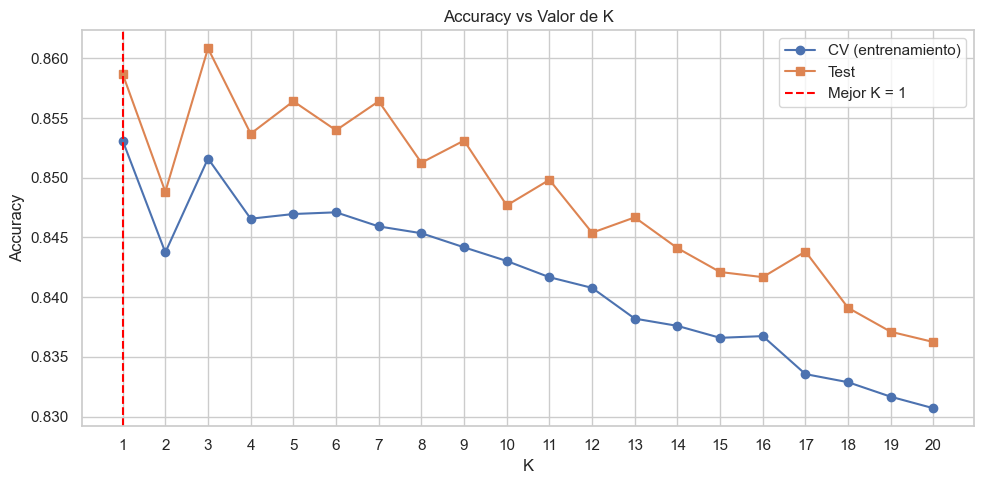

In [4]:
plt.figure(figsize=(10, 5))
plt.plot(rango_k, accuracies_cv,   marker='o', label='CV (entrenamiento)', color='#4C72B0')
plt.plot(rango_k, accuracies_test, marker='s', label='Test',               color='#DD8452')
plt.axvline(x=mejor_k, color='red', linestyle='--', label=f'Mejor K = {mejor_k}')
plt.title('Accuracy vs Valor de K')
plt.xlabel('K')
plt.ylabel('Accuracy')
plt.xticks(rango_k)
plt.legend()
plt.tight_layout()
plt.savefig('outputs/figures/knn_accuracy_vs_k.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Entrenar el modelo final con el mejor K

In [ ]:
knn_final = KNeighborsClassifier(n_neighbors=mejor_k)
knn_final.fit(X_train, y_train)
y_pred_knn = knn_final.predict(X_test)

print(f'✅ Modelo KNN entrenado con K = {mejor_k}')

## 5. Métricas de evaluación

In [ ]:
acc = accuracy_score(y_test, y_pred_knn)
print(f'Accuracy: {acc:.4f} ({acc*100:.2f}%)')
print('\nReporte de clasificación:')
print(classification_report(y_test, y_pred_knn, target_names=CLASES))

## 6. Matriz de confusión

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Valores absolutos
cm = confusion_matrix(y_test, y_pred_knn)
ConfusionMatrixDisplay(cm, display_labels=CLASES).plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title(f'Matriz de Confusión — KNN (K={mejor_k})')
axes[0].tick_params(axis='x', rotation=15)

# Valores porcentuales
cm_pct = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
ConfusionMatrixDisplay(np.round(cm_pct, 2), display_labels=CLASES).plot(ax=axes[1], colorbar=False, cmap='Blues')
axes[1].set_title('Matriz de Confusión — Porcentajes')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig('outputs/figures/knn_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Guardar resultados

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

resultados_knn = pd.DataFrame([{
    'Modelo':    'KNN',
    'Mejor_K':   mejor_k,
    'Accuracy':  round(accuracy_score(y_test, y_pred_knn), 4),
    'Precision': round(precision_score(y_test, y_pred_knn, average='weighted'), 4),
    'Recall':    round(recall_score(y_test, y_pred_knn, average='weighted'), 4),
    'F1_Score':  round(f1_score(y_test, y_pred_knn, average='weighted'), 4)
}])

resultados_knn.to_csv('outputs/results/resultados_knn.csv', index=False)
print('✅ Resultados guardados en outputs/results/resultados_knn.csv')
print(resultados_knn.to_string(index=False))
print('\n✅ KNN completado. Continúa con 04_decision_tree.ipynb')